In [ ]:
from pathlib import Path
import torch
import random
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_DIR = PROJECT_ROOT / "data" / "train"
VAL_DIR   = PROJECT_ROOT / "data" / "val"
TEST_DIR  = PROJECT_ROOT / "data" / "test"


print("TRAIN:", TRAIN_DIR)
print("VAL  :", VAL_DIR)
print("TEST :", TEST_DIR)

TRAIN: c:\CNN\TP_detekcia_defektov\classification\train
VAL  : c:\CNN\TP_detekcia_defektov\classification\val
TEST : c:\CNN\TP_detekcia_defektov\classification\test


In [ ]:

IMG_SIZE = 224
BATCH_SIZE = 32

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=eval_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)


g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)


class_names = train_ds.classes
num_classes = len(class_names)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [ ]:
import torchvision.models as models
from torch import nn

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_classes = len(class_names)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx=None):
        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[:, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = cam / cam.max()

        return cam

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def eval_model(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            total_loss += loss.item() * X.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [ ]:
target_layer = model.layer4[-1].conv2

grad_cam = GradCAM(model, target_layer)

In [ ]:
EPOCHS = 3
train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = eval_model(model, val_loader)

    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"train_acc={train_acc:.3f} val_acc={val_acc:.3f} | "
          f"train_loss={train_loss:.3f} val_loss={val_loss:.3f}")

Epoch 1/3 | train_acc=0.794 val_acc=0.894 | train_loss=0.589 val_loss=0.360
Epoch 2/3 | train_acc=0.983 val_acc=0.990 | train_loss=0.081 val_loss=0.088
Epoch 3/3 | train_acc=0.994 val_acc=0.981 | train_loss=0.039 val_loss=0.074


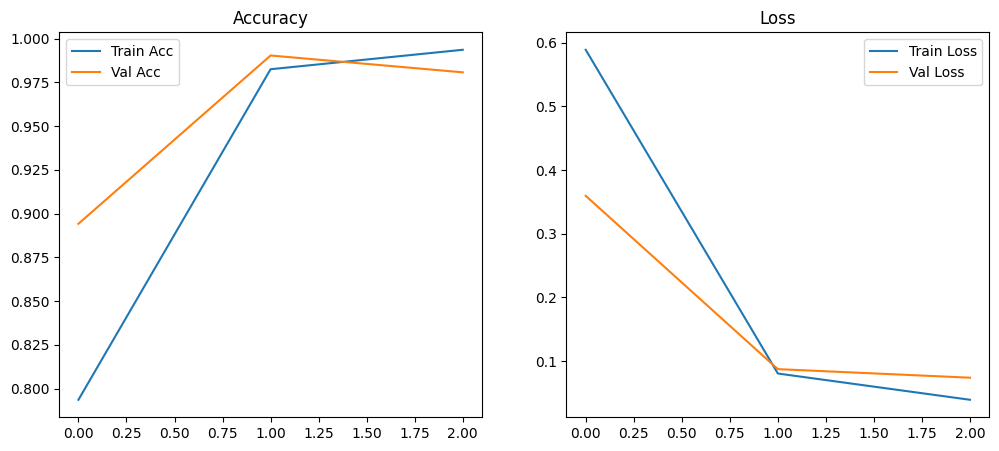

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(val_acc_hist, label="Val Acc")
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.legend(); plt.title("Loss")

plt.show()

Test accuracy: 0.972972972972973
              precision    recall  f1-score   support

        bad1       1.00      0.94      0.97        18
        bad2       1.00      1.00      1.00        12
        bad3       0.91      1.00      0.95        20
        bad4       0.94      1.00      0.97        15
        good       1.00      0.96      0.98        46

    accuracy                           0.97       111
   macro avg       0.97      0.98      0.97       111
weighted avg       0.98      0.97      0.97       111



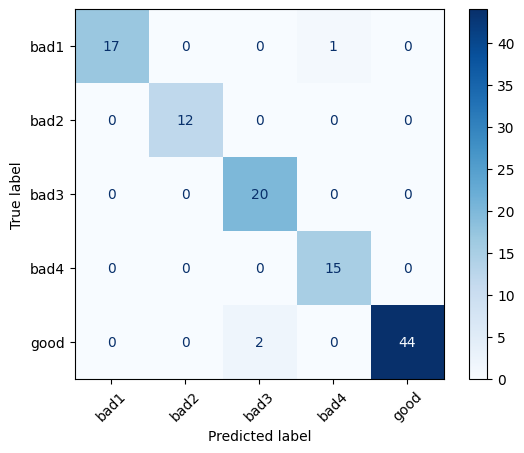

In [ ]:
test_loss, test_acc = eval_model(model, test_loader)
print("Test accuracy:", test_acc)

all_true, all_pred = [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_pred.extend(preds)
        all_true.extend(y.numpy())

print(classification_report(all_true, all_pred, target_names=class_names))

cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap="Blues"); plt.xticks(rotation=45); plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_gradcam_n_per_class(
    model,
    grad_cam,
    loader,
    class_names,
    n_per_class=5
):
    model.eval()

    class_counter = {cls: 0 for cls in class_names}

    n_classes = len(class_names)
    total_plots = n_classes * n_per_class

    plt.figure(figsize=(4 * n_per_class, 4 * n_classes))
    plot_idx = 1

    for images, labels in loader:
        images = images.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for i in range(images.size(0)):
            pred_idx = preds[i].item()
            class_name = class_names[pred_idx]

            if class_counter[class_name] >= n_per_class:
                continue

            cam = grad_cam(images[i:i+1])
            img = images[i].cpu()

            img_np = img.permute(1, 2, 0).numpy()
            H, W, _ = img_np.shape
            cam_resized = cv2.resize(cam, (W, H))

            heatmap = cv2.applyColorMap(
                np.uint8(255 * cam_resized),
                cv2.COLORMAP_JET
            )
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
            overlay = 0.6 * img_np + 0.4 * (heatmap / 255)

            plt.subplot(n_classes, n_per_class, plot_idx)
            plt.imshow(overlay)
            plt.title(class_name, fontsize=9)
            plt.axis("off")

            plot_idx += 1
            class_counter[class_name] += 1

            if all(class_counter[c] >= n_per_class for c in class_names):
                plt.tight_layout()
                plt.show()
                return

    plt.tight_layout()
    plt.show()


c:\Users\Šimon\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


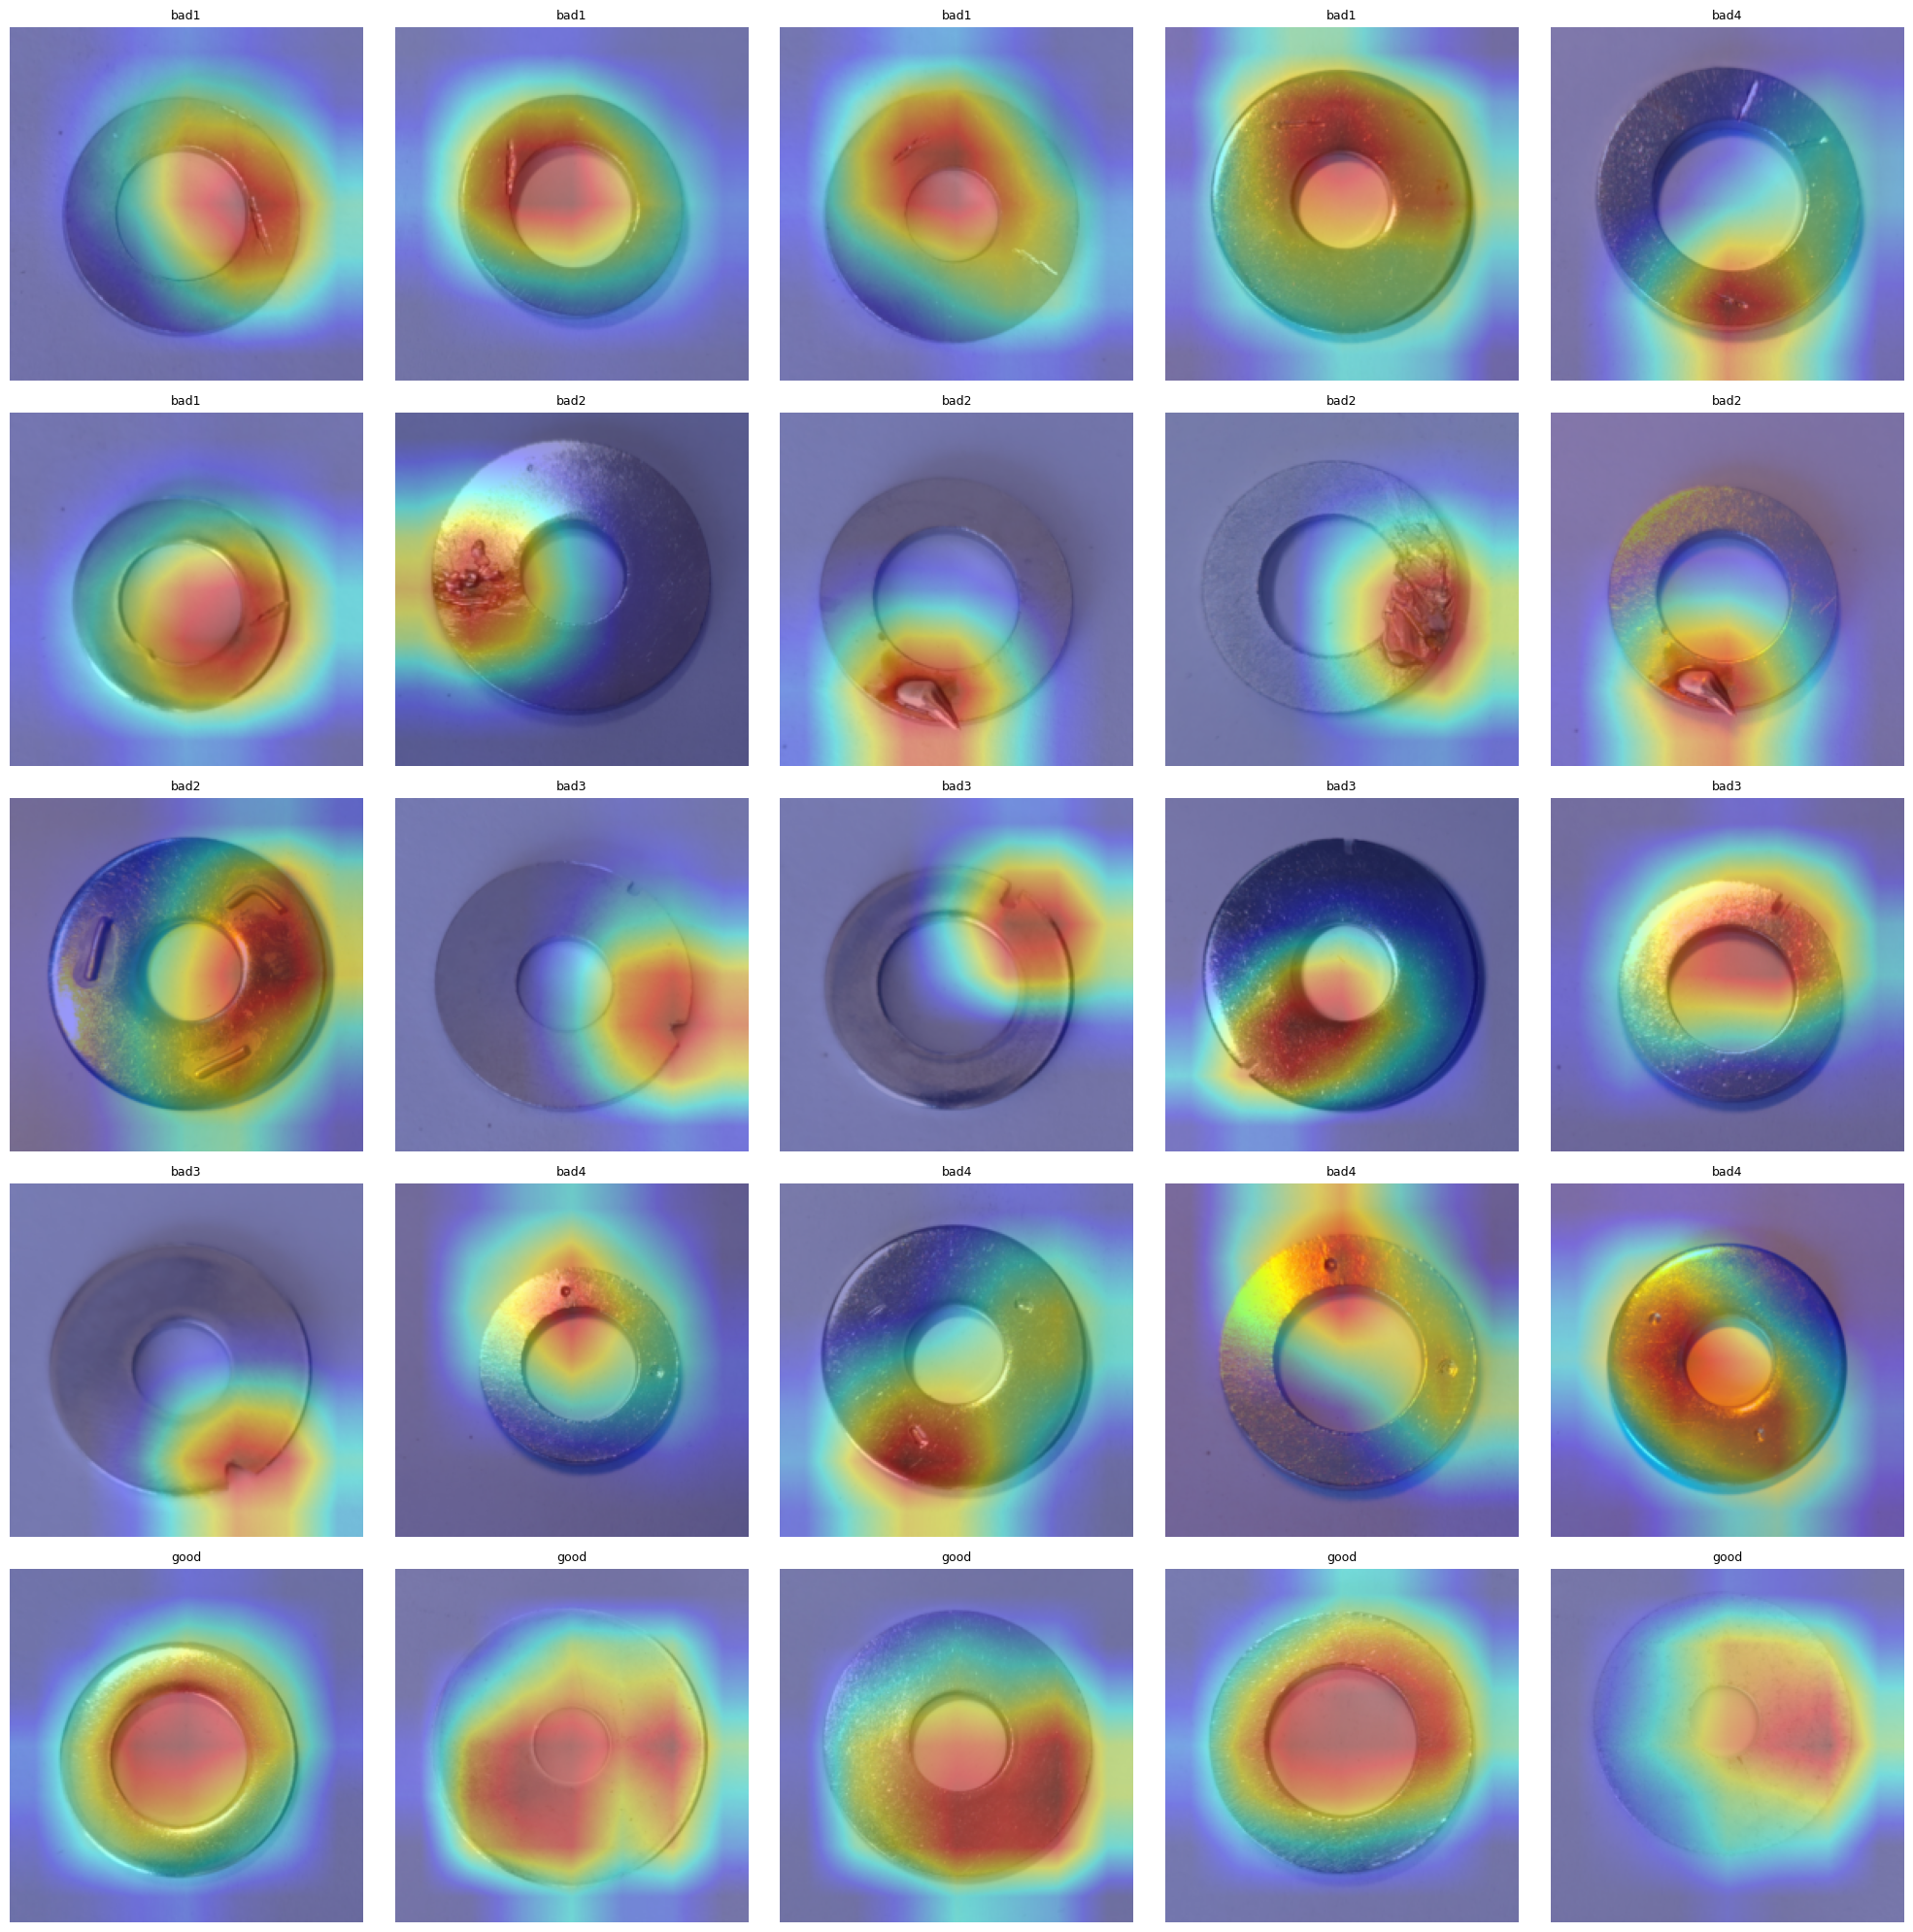

In [ ]:
show_gradcam_n_per_class(
    model=model,
    grad_cam=grad_cam,
    loader=test_loader,
    class_names=class_names,
    n_per_class=5
)

In [ ]:

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
torch.save(model.state_dict(), MODEL_DIR / "keras_like_cnn_multiclass.pth")
